# Network Intrusion Detection with the NSL-KDD Dataset

**Final Project – Reproduction and Critical Evaluation**  
**Student:** Noor Zerene                 
**ID:** 212015168

## Selected source

This project critically evaluates and extends the public GitHub project:

**Mert Eroglu and Müslüm Sezgin, “NSL-KDD Network Intrusion Detection.”**

- Original repository:  
  `https://github.com/Mamcose/NSL-KDD-Network-Intrusion-Detection`
- Dataset backup:  
  `https://github.com/jmnwong/NSL-KDD-Dataset`
- Dataset description:  
  `https://www.unb.ca/cic/datasets/nsl.html`

The original repository applies Random Forest, K-Nearest Neighbors, Support Vector Classification, and ensemble learning to the NSL-KDD dataset and compares model accuracy.

## Project objective

The goal of this notebook is not only to run intrusion-detection models, but also to investigate whether the original project's conclusions are supported by a rigorous evaluation.

The notebook addresses the following questions:

1. Can machine-learning models distinguish normal network connections from attacks?
2. Is accuracy sufficient for evaluating a Network Intrusion Detection System?
3. Which model produces the best balance between attack recall and false alarms?
4. Which attack categories are most difficult to detect?
5. Which features contribute most to the predictions?
6. How reproducible and realistic is the original project?

## Main improvements over the selected source

- explicit data-quality analysis;
- missing-value and duplicate checks;
- temporal limitations discussion;
- categorical and numerical EDA;
- class-prevalence analysis;
- outlier analysis;
- feature redundancy analysis;
- preprocessing inside leakage-safe pipelines;
- comparison with a dummy baseline;
- cross-validation on the training data;
- evaluation on the official unseen NSL-KDD test set;
- Accuracy, Precision, Recall, F1, F2, MCC, ROC-AUC, and confusion matrices;
- attack-family error analysis;
- threshold analysis;
- permutation feature importance;
- critical evaluation of the original claims.

## 1. Imports and reproducibility

A fixed random seed is used wherever randomness is involved.

In [1]:
import sys
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

Python: 3.12.13
NumPy: 2.0.2
pandas: 2.2.2


## Google Colab compatibility note

This version was adjusted for current Google Colab and recent scikit-learn versions.

In particular, the F2 scorer used by permutation importance is created explicitly with `make_scorer`, because `"f2"` is not a built-in scikit-learn scoring string.

Run the notebook using:

**Runtime → Run all**

If a previous version of the notebook was already executed in the same session, restart the runtime first to avoid keeping old variables.

## 2. Dataset description

NSL-KDD is a revised version of KDD Cup 1999. It was designed to reduce the effect of duplicated and overly easy records in the older dataset.

Each row represents one network connection. The dataset contains:

- 41 input features;
- an attack label;
- a difficulty score;
- numerical traffic features;
- three categorical features: `protocol_type`, `service`, and `flag`.

The official train and test sets are intentionally different. The test set contains attack types that are not necessarily represented in the same way in the training set. This makes the evaluation harder and more realistic than randomly splitting one file.

In [2]:
COLUMN_NAMES = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack",
    "difficulty"
]

TRAIN_URLS = [
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain+.txt",
    "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
]

TEST_URLS = [
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest+.txt",
    "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"
]

TRAIN_PATH = Path("KDDTrain+.txt")
TEST_PATH = Path("KDDTest+.txt")


def download_with_fallback(urls, output_path):
    if output_path.exists():
        print(f"Using local file: {output_path}")
        return

    last_error = None

    for url in urls:
        try:
            print(f"Trying to download {output_path.name}...")
            urlretrieve(url, output_path)
            print("Download completed.")
            return
        except Exception as error:
            last_error = error

    raise RuntimeError(
        f"Could not download {output_path.name}. "
        "Download KDDTrain+.txt and KDDTest+.txt manually from the dataset "
        "repository and place them in the notebook folder."
    ) from last_error


def load_nsl_kdd():
    download_with_fallback(TRAIN_URLS, TRAIN_PATH)
    download_with_fallback(TEST_URLS, TEST_PATH)

    train_data = pd.read_csv(
        TRAIN_PATH,
        header=None,
        names=COLUMN_NAMES
    )

    test_data = pd.read_csv(
        TEST_PATH,
        header=None,
        names=COLUMN_NAMES
    )

    return train_data, test_data


train_df, test_df = load_nsl_kdd()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)
display(train_df.head())

Trying to download KDDTrain+.txt...
Download completed.
Trying to download KDDTest+.txt...
Download completed.
Training shape: (125973, 43)
Testing shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Initial data inspection

This section checks:

- dimensions;
- column and index names;
- feature types;
- missing values;
- duplicated rows;
- constant columns;
- label values;
- invalid or suspicious values.

In [3]:
print("Training index name:", train_df.index.name)
print("Testing index name:", test_df.index.name)
print("Training index type:", type(train_df.index).__name__)
print("Number of input features:", len(COLUMN_NAMES) - 2)

dtype_summary = pd.DataFrame({
    "train_dtype": train_df.dtypes.astype(str),
    "test_dtype": test_df.dtypes.astype(str),
    "train_unique": train_df.nunique(),
    "test_unique": test_df.nunique(),
    "train_missing": train_df.isna().sum(),
    "test_missing": test_df.isna().sum()
})

display(dtype_summary)

Training index name: None
Testing index name: None
Training index type: RangeIndex
Number of input features: 41


,train_dtype,test_dtype,train_unique,test_unique,train_missing,test_missing
duration,int64,int64,2981,624,0,0
protocol_type,object,object,3,3,0,0
service,object,object,70,64,0,0
flag,object,object,11,11,0,0
src_bytes,int64,int64,3341,1149,0,0
dst_bytes,int64,int64,9326,3650,0,0
land,int64,int64,2,2,0,0
wrong_fragment,int64,int64,3,3,0,0
urgent,int64,int64,4,4,0,0
hot,int64,int64,28,16,0,0


### Index and column-name discussion

The default integer index is acceptable because the dataset does not include a connection identifier. It should not be used as an input feature.

The descriptive column names are meaningful because they distinguish:

- basic connection properties;
- content-related security indicators;
- short-window traffic statistics;
- destination-host statistics;
- categorical network protocol information.

The `difficulty` column is metadata created during the construction of NSL-KDD. It is not a property that would normally be known when detecting a live attack. Therefore, it must not be used as a model feature.

In [4]:
quality_summary = pd.DataFrame({
    "train": [
        len(train_df),
        train_df.isna().sum().sum(),
        train_df.duplicated().sum(),
        train_df.drop(columns=["attack", "difficulty"]).duplicated().sum()
    ],
    "test": [
        len(test_df),
        test_df.isna().sum().sum(),
        test_df.duplicated().sum(),
        test_df.drop(columns=["attack", "difficulty"]).duplicated().sum()
    ]
}, index=[
    "rows",
    "missing_values",
    "exact_duplicate_rows",
    "duplicate_feature_vectors"
])

display(quality_summary)

,train,test
rows,125973,22544
missing_values,0,0
exact_duplicate_rows,0,0
duplicate_feature_vectors,16,57


In [5]:
feature_columns = [
    column for column in COLUMN_NAMES
    if column not in ["attack", "difficulty"]
]

constant_train_features = [
    column for column in feature_columns
    if train_df[column].nunique(dropna=False) <= 1
]

constant_test_features = [
    column for column in feature_columns
    if test_df[column].nunique(dropna=False) <= 1
]

print("Constant training features:", constant_train_features)
print("Constant testing features:", constant_test_features)

Constant training features: ['num_outbound_cmds']
Constant testing features: ['num_outbound_cmds']


### Data-quality decisions

- Missing values will be handled inside preprocessing pipelines if any are found.
- Exact duplicates are reported but not automatically deleted because NSL-KDD was already designed to reduce redundant records.
- A constant training feature contains no information for model learning and will be removed.
- `difficulty` is removed to avoid using unavailable metadata.
- The original multiclass attack name is preserved for later error analysis.
- A binary target is created: normal = 0 and attack = 1.

In [6]:
constant_features = sorted(set(constant_train_features))

train_clean = train_df.drop(columns=constant_features).copy()
test_clean = test_df.drop(columns=constant_features).copy()

train_clean["target"] = (train_clean["attack"] != "normal").astype(int)
test_clean["target"] = (test_clean["attack"] != "normal").astype(int)

print("Removed features:", constant_features)
print("Training shape after removal:", train_clean.shape)
print("Testing shape after removal:", test_clean.shape)

Removed features: ['num_outbound_cmds']
Training shape after removal: (125973, 43)
Testing shape after removal: (22544, 43)


## 4. Temporal analysis

The assignment asks for temporal analysis when temporal information exists.

NSL-KDD does **not** contain timestamps or collection dates for individual connections. The row index is not documented as chronological. The `duration` feature describes the length of a connection, not the date or time when it occurred.

Therefore:

- a chronological train/test split cannot be created;
- concept drift cannot be measured;
- seasonality cannot be analyzed;
- the age of the dataset is a serious external-validity limitation.

Modern network protocols, applications, encryption, cloud services, and attacker behavior have changed substantially since the original traffic was produced. Good performance on NSL-KDD does not prove good performance on current traffic.

In [7]:
temporal_candidates = [
    column for column in train_clean.columns
    if any(token in column.lower() for token in [
        "date", "timestamp", "year", "month", "hour", "minute"
    ])
]

print("True temporal columns found:", temporal_candidates)
print(
    "The feature 'duration' is a connection-length measurement, "
    "not a timestamp."
)

True temporal columns found: []
The feature 'duration' is a connection-length measurement, not a timestamp.


## 5. Target and attack-family creation

The original labels contain many specific attack names. For binary classification:

- `0` means normal traffic;
- `1` means attack traffic.

For error analysis, attacks are also mapped into four traditional families:

- **DoS:** denial-of-service attacks;
- **Probe:** network scanning and information gathering;
- **R2L:** remote-to-local unauthorized access;
- **U2R:** user-to-root privilege escalation.

In [8]:
DOS_ATTACKS = {
    "back", "land", "neptune", "pod", "smurf", "teardrop",
    "apache2", "udpstorm", "processtable", "worm", "mailbomb"
}

PROBE_ATTACKS = {
    "satan", "ipsweep", "nmap", "portsweep",
    "mscan", "saint"
}

R2L_ATTACKS = {
    "guess_passwd", "ftp_write", "imap", "phf", "multihop",
    "warezmaster", "warezclient", "spy", "xlock", "xsnoop",
    "snmpguess", "snmpgetattack", "httptunnel", "sendmail",
    "named"
}

U2R_ATTACKS = {
    "buffer_overflow", "loadmodule", "rootkit", "perl",
    "sqlattack", "xterm", "ps"
}


def map_attack_family(label):
    if label == "normal":
        return "Normal"
    if label in DOS_ATTACKS:
        return "DoS"
    if label in PROBE_ATTACKS:
        return "Probe"
    if label in R2L_ATTACKS:
        return "R2L"
    if label in U2R_ATTACKS:
        return "U2R"
    return "Other attack"


train_clean["attack_family"] = train_clean["attack"].apply(map_attack_family)
test_clean["attack_family"] = test_clean["attack"].apply(map_attack_family)

print("Training attack families:")
display(train_clean["attack_family"].value_counts().to_frame("count"))

print("Testing attack families:")
display(test_clean["attack_family"].value_counts().to_frame("count"))

Training attack families:


,count
attack_family,
Normal,67343
DoS,45927
Probe,11656
R2L,995
U2R,52


Testing attack families:


,count
attack_family,
Normal,9711
DoS,7460
R2L,2885
Probe,2421
U2R,67


## 6. Exploratory Data Analysis

### 6.1 Class prevalence

Class prevalence is the proportion of attacks in the data.

In a real Security Operations Center, attack prevalence may be much lower than in a benchmark dataset. A model evaluated on an artificially attack-heavy dataset can have a precision that does not transfer to deployment.

False-negative and false-positive meanings:

- **False negative:** an attack is accepted as normal. This can allow compromise or data loss.
- **False positive:** normal traffic is flagged as an attack. This creates analyst workload and alert fatigue.

In [9]:
def class_summary(data, name):
    counts = data["target"].value_counts().sort_index()
    proportions = data["target"].value_counts(normalize=True).sort_index()

    result = pd.DataFrame({
        "count": counts,
        "percentage": (proportions * 100).round(2)
    })

    result.index = ["Normal", "Attack"]
    result.index.name = name
    return result


display(class_summary(train_clean, "Training class"))
display(class_summary(test_clean, "Testing class"))

,count,percentage
Training class,,
Normal,67343,53.46
Attack,58630,46.54


,count,percentage
Testing class,,
Normal,9711,43.08
Attack,12833,56.92


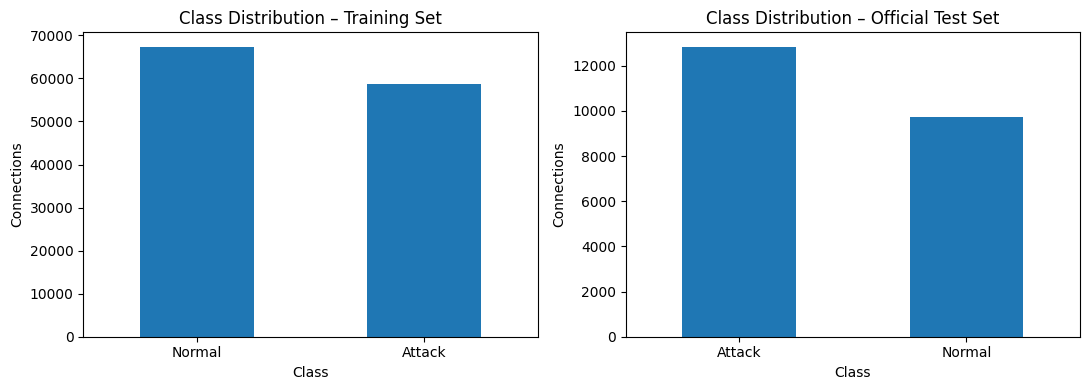

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for axis, data, title in [
    (axes[0], train_clean, "Training Set"),
    (axes[1], test_clean, "Official Test Set")
]:
    counts = data["target"].map({0: "Normal", 1: "Attack"}).value_counts()
    counts.plot(kind="bar", ax=axis)
    axis.set_title(f"Class Distribution – {title}")
    axis.set_xlabel("Class")
    axis.set_ylabel("Connections")
    axis.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The class distribution shows that the NSL-KDD dataset is not perfectly balanced. Attack traffic represents a large proportion of the dataset, especially in the official test set. This differs from many real enterprise environments, where attacks are much rarer than normal traffic.

This observation is important because evaluation metrics such as accuracy can become misleading when the deployment distribution differs from the benchmark distribution. Therefore, precision, recall, F1-score, F2-score, and Matthews Correlation Coefficient are also evaluated throughout this project.

### 6.2 Attack-type distributions

Comparing train and test attack families is important because a model may generalize differently to attack categories that are rare or absent during training.

,train_count,test_count
attack_family,,
Normal,67343,9711
DoS,45927,7460
Probe,11656,2421
R2L,995,2885
U2R,52,67


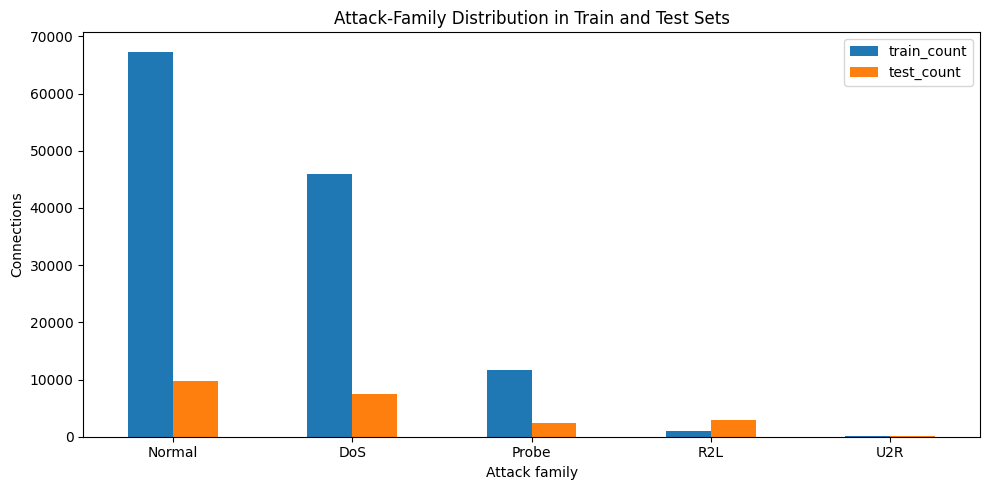

In [11]:
family_table = pd.concat(
    [
        train_clean["attack_family"].value_counts().rename("train_count"),
        test_clean["attack_family"].value_counts().rename("test_count")
    ],
    axis=1
).fillna(0).astype(int)

display(family_table)

family_table.plot(kind="bar", figsize=(10, 5))
plt.title("Attack-Family Distribution in Train and Test Sets")
plt.xlabel("Attack family")
plt.ylabel("Connections")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The attack-family distribution reveals a strong imbalance between attack categories. Denial-of-Service (DoS) attacks are much more common than User-to-Root (U2R) and Remote-to-Local (R2L) attacks.

Because machine-learning models generally perform better on well-represented classes, we expect lower detection rates for the rare attack families. Later sections verify whether this expectation is reflected in the experimental results.

### 6.3 Missing-value analysis

In [12]:
missing_table = pd.DataFrame({
    "train_missing": train_clean.isna().sum(),
    "train_percent": train_clean.isna().mean() * 100,
    "test_missing": test_clean.isna().sum(),
    "test_percent": test_clean.isna().mean() * 100
}).sort_values("train_missing", ascending=False)

display(missing_table.head(15))

print("Total training missing values:", train_clean.isna().sum().sum())
print("Total testing missing values:", test_clean.isna().sum().sum())

,train_missing,train_percent,test_missing,test_percent
duration,0,0.0,0,0.0
protocol_type,0,0.0,0,0.0
service,0,0.0,0,0.0
flag,0,0.0,0,0.0
src_bytes,0,0.0,0,0.0
dst_bytes,0,0.0,0,0.0
land,0,0.0,0,0.0
wrong_fragment,0,0.0,0,0.0
urgent,0,0.0,0,0.0
hot,0,0.0,0,0.0


Total training missing values: 0
Total testing missing values: 0


### 6.4 Categorical feature analysis

The three categorical predictors are:

- `protocol_type`;
- `service`;
- `flag`.

Frequency tables and attack rates are more appropriate for these variables than means or standard deviations.

In [13]:
categorical_features = ["protocol_type", "service", "flag"]

for feature in categorical_features:
    print("=" * 70)
    print(feature)
    print("=" * 70)

    table = pd.crosstab(
        train_clean[feature],
        train_clean["target"],
        normalize="index"
    ).rename(columns={0: "normal_rate", 1: "attack_rate"})

    counts = train_clean[feature].value_counts().rename("count")
    table = table.join(counts)
    table = table.sort_values("count", ascending=False)

    display(table.head(20))

protocol_type


,normal_rate,attack_rate,count
protocol_type,,,
tcp,0.521964,0.478036,102689
udp,0.829320,0.170680,14993
icmp,0.157882,0.842118,8291


service


,normal_rate,attack_rate,count
service,,,
http,0.943254,0.056746,40338
private,0.044937,0.955063,21853
domain_u,0.999005,0.000995,9043
smtp,0.961165,0.038835,7313
ftp_data,0.726531,0.273469,6860
eco_i,0.108373,0.891627,4586
other,0.597385,0.402615,4359
ecr_i,0.061748,0.938252,3077
telnet,0.389715,0.610285,2353


flag


,normal_rate,attack_rate,count
flag,,,
SF,0.845860,0.154140,74945
S0,0.010158,0.989842,34851
REJ,0.239740,0.760260,11233
RSTR,0.060306,0.939694,2421
RSTO,0.140205,0.859795,1562
S1,0.989041,0.010959,365
SH,0.007380,0.992620,271
S2,0.937008,0.062992,127
RSTOS0,0.000000,1.000000,103


### 6.5 Numerical feature distributions

Cybersecurity traffic variables are usually strongly skewed. For example, most connections may transfer relatively few bytes, while a small number transfer very large amounts.

Logarithmic transformations are used only for visualization here. The transformation is:

\[
x' = \log(1+x)
\]

Adding one allows zero values to be transformed safely.

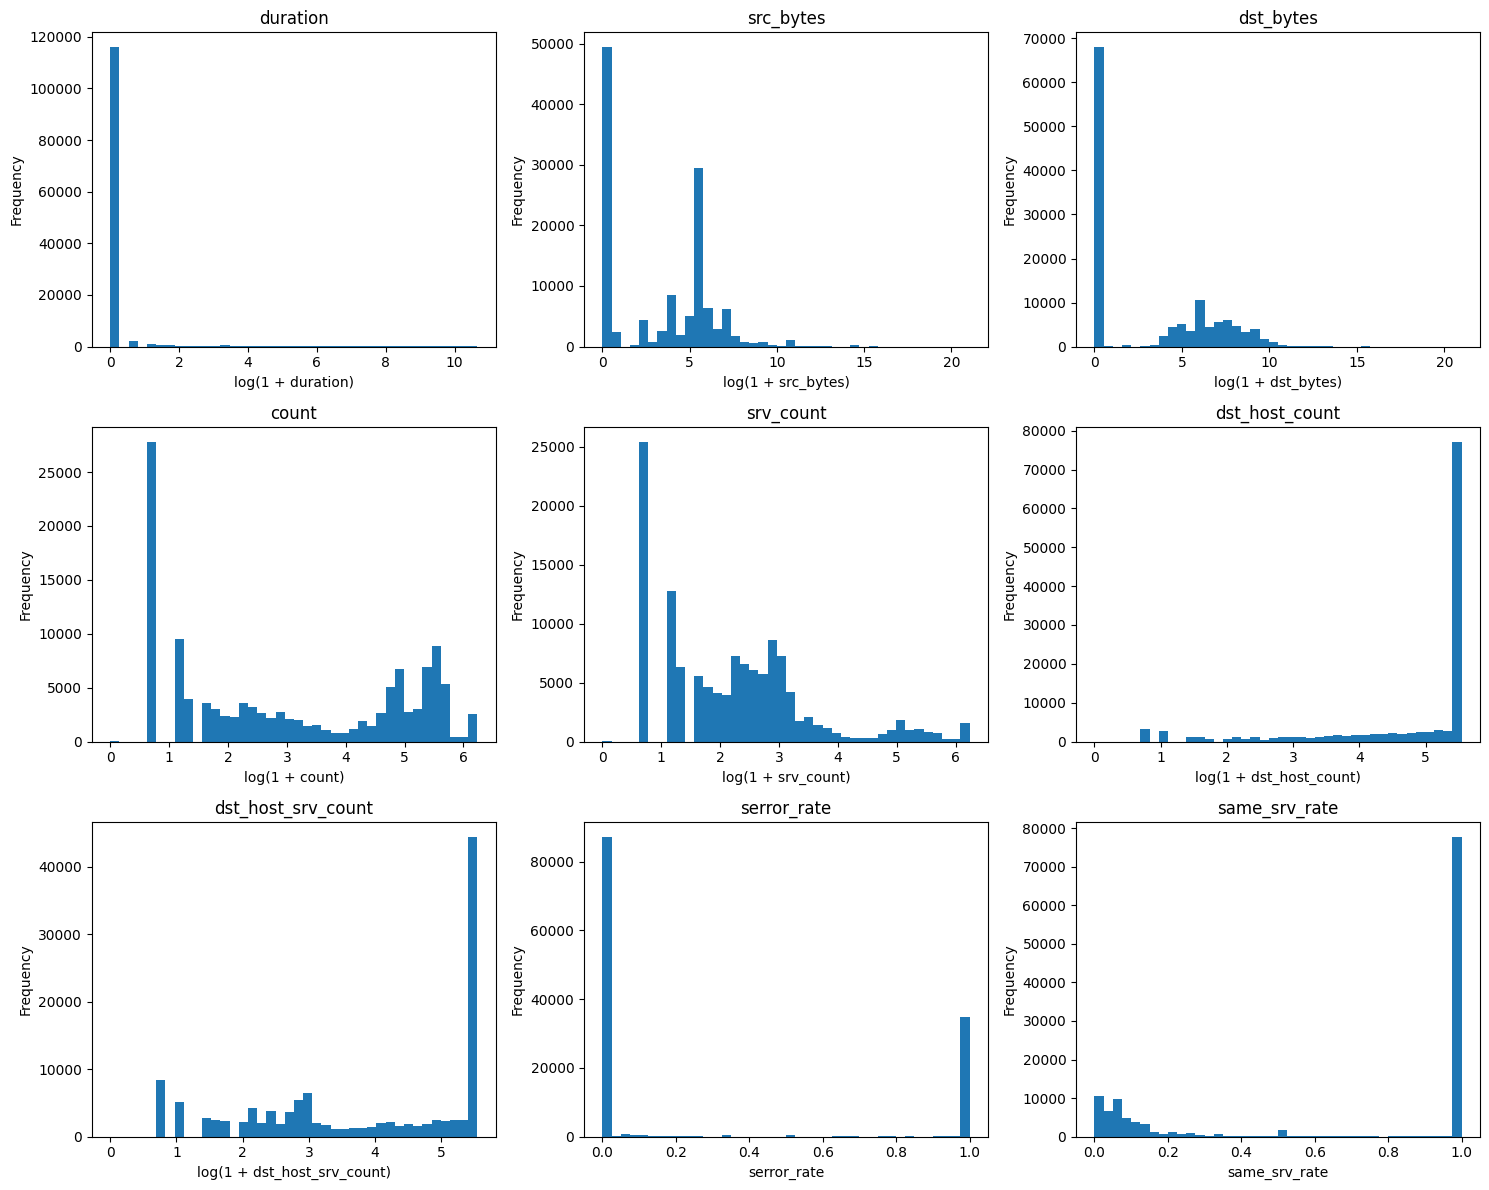

In [14]:
selected_numeric_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count",
    "serror_rate",
    "same_srv_rate"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for axis, feature in zip(axes, selected_numeric_features):
    values = train_clean[feature]

    if values.max() > 10:
        plot_values = np.log1p(values)
        x_label = f"log(1 + {feature})"
    else:
        plot_values = values
        x_label = feature

    axis.hist(plot_values, bins=40)
    axis.set_title(feature)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 6.6 Group-by analysis

The following table compares selected feature averages between normal and attack traffic.

For highly skewed variables, medians are also reported because they are more robust than means.

In [15]:
group_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "num_failed_logins",
    "logged_in",
    "count",
    "srv_count",
    "serror_rate",
    "rerror_rate",
    "same_srv_rate",
    "dst_host_srv_count",
    "dst_host_serror_rate"
]

group_summary = train_clean.groupby("target")[group_features].agg(
    ["mean", "median"]
)

group_summary.index = ["Normal", "Attack"]
display(group_summary.T)

Normal        Attack
duration             mean      168.587396    423.320689
                     median      0.000000      0.000000
src_bytes            mean    13133.279331  82820.141327
                     median    233.000000      0.000000
dst_bytes            mean     4329.685223  37524.482159
                     median    379.000000      0.000000
wrong_fragment       mean        0.000000      0.048746
                     median      0.000000      0.000000
num_failed_logins    mean        0.001381      0.001040
                     median      0.000000      0.000000
logged_in            mean        0.710646      0.034027
                     median      1.000000      0.000000
count                mean       22.517945    154.849991
                     median      4.000000    138.000000
srv_count            mean       27.685654     27.797885
                     median      5.000000     10.000000
serror_rate          mean        0.013441      0.595808
                     median      0.000000      1.000000
rerror_rate          mean        0.044196      0.206980
                     median      0.000000      0.000000
same_srv_rate        mean        0.969360      0.306659
                     median      1.000000      0.080000
dst_host_srv_count   mean      190.285761     29.929081
                     median    255.000000     12.000000
dst_host_serror_rate mean        0.013930      0.595177
                     median      0.000000      1.000000

### 6.7 Outlier analysis

Outliers are expected in network traffic. A very large byte count or unusually long connection may be:

- a measurement error;
- a legitimate large transfer;
- an attack signal.

Therefore, outliers are identified but not removed automatically.

The interquartile-range rule is used for numerical features:

\[
IQR = Q_3 - Q_1
\]

A value is flagged when it is below \(Q_1-1.5IQR\) or above \(Q_3+1.5IQR\).

This method is descriptive. It does not prove that a connection is malicious.

In [16]:
numerical_features = [
    column for column in feature_columns
    if column not in categorical_features
    and column not in constant_features
]


def iqr_outlier_summary(data, columns):
    records = []

    for feature in columns:
        q1 = data[feature].quantile(0.25)
        q3 = data[feature].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (data[feature] < lower) | (data[feature] > upper)

        records.append({
            "feature": feature,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "outlier_count": int(outlier_mask.sum()),
            "outlier_percent": float(outlier_mask.mean() * 100)
        })

    return (
        pd.DataFrame(records)
        .sort_values("outlier_percent", ascending=False)
        .reset_index(drop=True)
    )


outlier_summary = iqr_outlier_summary(train_clean, numerical_features)
display(outlier_summary.head(15).round(3))

,feature,q1,q3,iqr,outlier_count,outlier_percent
0,srv_diff_host_rate,0.0,0.00,0.00,28399,22.544
1,dst_host_same_src_port_rate,0.0,0.06,0.06,25052,19.887
2,dst_bytes,0.0,516.00,516.00,23579,18.718
3,dst_host_rerror_rate,0.0,0.00,0.00,22795,18.095
4,dst_host_srv_rerror_rate,0.0,0.00,0.00,19357,15.366
5,srv_rerror_rate,0.0,0.00,0.00,16206,12.865
6,rerror_rate,0.0,0.00,0.00,16190,12.852
7,src_bytes,0.0,276.00,276.00,13840,10.986
8,srv_count,2.0,18.00,16.00,12054,9.569
9,dst_host_srv_diff_host_rate,0.0,0.02,0.02,11682,9.273


### 6.8 Correlation analysis

#### Selected measure: Spearman correlation

Spearman correlation is selected for numerical features because:

- many variables are non-normal;
- several variables are bounded rates;
- byte and count features are strongly skewed;
- monotonic relationships may exist without being linear;
- Spearman is less sensitive to extreme values than Pearson.

Spearman correlation is the Pearson correlation between ranked values:

\[

ho_s = \operatorname{corr}(\operatorname{rank}(X),
                             \operatorname{rank}(Y))
\]

Limitations:

- correlation is not causation;
- pairwise correlation cannot capture all nonlinear interactions;
- high statistical association may not imply operational importance;
- correlated features can divide model importance between them.

In [17]:
spearman_data = train_clean[numerical_features + ["target"]]
spearman_corr = spearman_data.corr(method="spearman")

target_corr = (
    spearman_corr["target"]
    .drop("target")
    .sort_values(key=np.abs, ascending=False)
)

display(
    target_corr
    .rename("spearman_correlation_with_attack")
    .to_frame()
    .head(20)
)

,spearman_correlation_with_attack
dst_bytes,-0.751897
same_srv_rate,-0.734787
src_bytes,-0.710716
logged_in,-0.690171
dst_host_srv_count,-0.686376
diff_srv_rate,0.676865
serror_rate,0.655198
dst_host_same_srv_rate,-0.651088
dst_host_serror_rate,0.637506
srv_serror_rate,0.629811


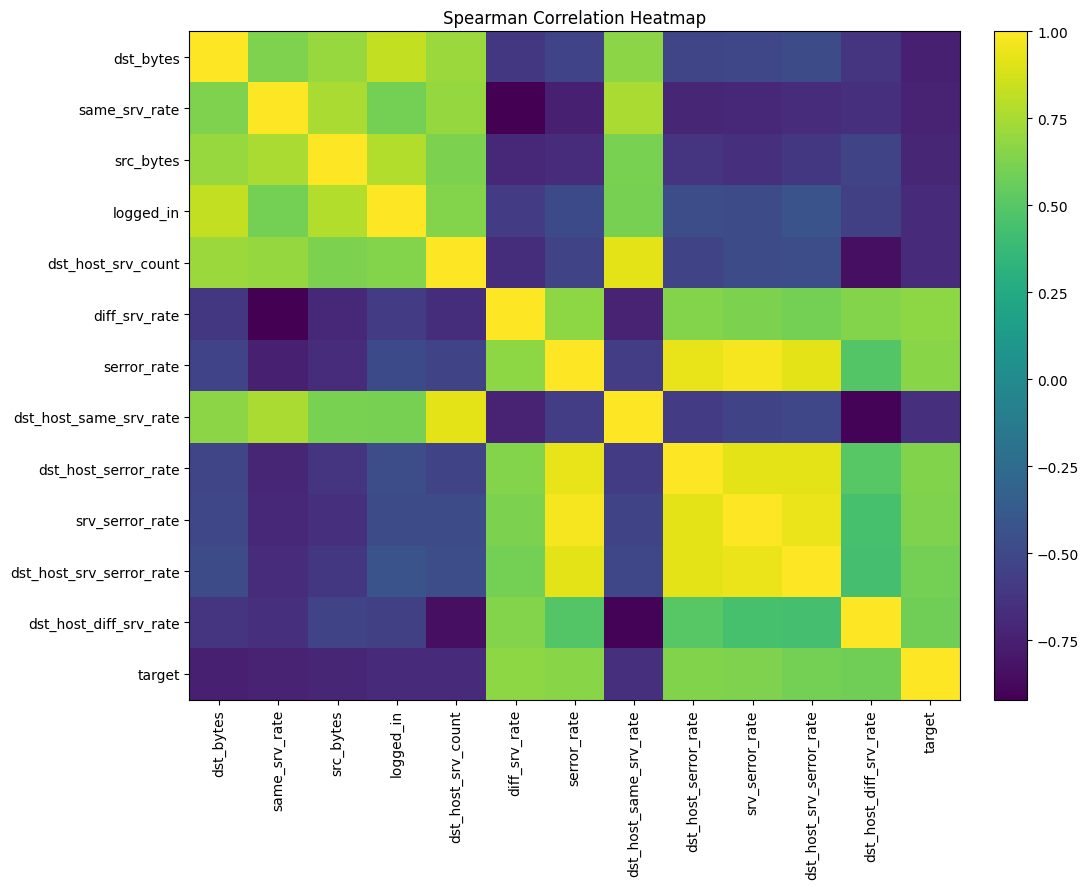

In [18]:
top_corr_features = target_corr.abs().head(12).index.tolist()
corr_matrix = train_clean[top_corr_features + ["target"]].corr(
    method="spearman"
)

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr_matrix, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Spearman Correlation Heatmap")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Interpretation

Several traffic statistics exhibit strong positive correlations, indicating that they capture related aspects of network behavior. Highly correlated variables may introduce redundancy into linear models and reduce interpretability.

However, redundancy does not necessarily imply that a feature should be removed. Tree-based models often benefit from correlated variables because they may capture complementary security patterns.

### 6.9 Redundancy analysis

Highly correlated features may represent overlapping statistics. Redundancy can:

- increase computation;
- reduce interpretability;
- make linear coefficients unstable;
- divide importance among similar features.

Pairs with absolute Spearman correlation of at least 0.90 are inspected. They are not removed automatically because related traffic statistics may still have different cybersecurity meanings.

In [19]:
numeric_corr_abs = train_clean[numerical_features].corr(
    method="spearman"
).abs()

upper_triangle = numeric_corr_abs.where(
    np.triu(np.ones(numeric_corr_abs.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "absolute_spearman_correlation"
    })
)

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["absolute_spearman_correlation"] >= 0.90
    ]
    .sort_values(
        "absolute_spearman_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(high_corr_pairs)

,feature_1,feature_2,absolute_spearman_correlation
0,serror_rate,srv_serror_rate,0.973119
1,rerror_rate,srv_rerror_rate,0.965777
2,srv_serror_rate,dst_host_srv_serror_rate,0.942332
3,serror_rate,dst_host_serror_rate,0.935943
4,serror_rate,dst_host_srv_serror_rate,0.921663
5,same_srv_rate,diff_srv_rate,0.920431
6,dst_host_serror_rate,dst_host_srv_serror_rate,0.919490
7,dst_host_srv_count,dst_host_same_srv_rate,0.919323
8,srv_serror_rate,dst_host_serror_rate,0.918676


## 7. Feature engineering

### 7.1 Removed features

- `difficulty` is removed because it would not be known in a live IDS.
- constant training features are removed because they cannot separate classes.
- `attack` and `attack_family` are retained only for analysis, not as predictors.

### 7.2 Categorical encoding

One-hot encoding is used for `protocol_type`, `service`, and `flag`.

Why?

- these categories have no correct numerical order;
- assigning arbitrary numbers could create false distances;
- one-hot encoding allows each category to have a separate model effect.

`handle_unknown="ignore"` is essential because the official test set may contain categories that are absent from training.

### 7.3 Numerical transformation

A custom `log1p` transformation is applied to strongly skewed non-negative count and byte features. This compresses extreme values while keeping zero valid.

Standardization is used for logistic regression because its optimization and coefficient scale benefit from comparable feature magnitudes.

Tree models do not require scaling, so they use a separate preprocessing pipeline.

### 7.4 Engineered features

The following domain-informed features are added:

- total bytes = source bytes + destination bytes;
- byte ratio;
- total error rate;
- total host error rate;
- connection intensity = count + service count.

These summarize traffic volume and error behavior.

In [20]:
SKEWED_LOG_FEATURES = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "num_compromised",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count"
]


def add_engineered_features(data):
    result = data.copy()

    result["total_bytes"] = (
        result["src_bytes"] + result["dst_bytes"]
    )

    result["src_dst_byte_ratio"] = (
        result["src_bytes"] / (result["dst_bytes"] + 1)
    )

    result["total_error_rate"] = (
        result["serror_rate"] + result["rerror_rate"]
    )

    result["total_host_error_rate"] = (
        result["dst_host_serror_rate"]
        + result["dst_host_rerror_rate"]
    )

    result["connection_intensity"] = (
        result["count"] + result["srv_count"]
    )

    return result


train_model_df = add_engineered_features(train_clean)
test_model_df = add_engineered_features(test_clean)

ENGINEERED_FEATURES = [
    "total_bytes",
    "src_dst_byte_ratio",
    "total_error_rate",
    "total_host_error_rate",
    "connection_intensity"
]

display(train_model_df[ENGINEERED_FEATURES].head())

,total_bytes,src_dst_byte_ratio,total_error_rate,total_host_error_rate,connection_intensity
0,491,491.000000,0.0,0.05,4
1,146,146.000000,0.0,0.00,14
2,0,0.000000,1.0,1.00,129
3,8385,0.028452,0.2,0.03,10
4,619,0.472684,0.0,0.00,62


## 8. Leakage-safe model matrices

The official test set is kept untouched until final evaluation.

Cross-validation is performed only on the official training set. Preprocessing is fitted inside each fold through scikit-learn pipelines.

In [21]:
excluded_columns = [
    "attack",
    "attack_family",
    "difficulty",
    "target"
]

X_train = train_model_df.drop(columns=excluded_columns)
y_train = train_model_df["target"]

X_test = test_model_df.drop(columns=excluded_columns)
y_test = test_model_df["target"]

attack_labels_test = test_model_df["attack"]
attack_families_test = test_model_df["attack_family"]

categorical_features_model = [
    feature for feature in categorical_features
    if feature in X_train.columns
]

numerical_features_model = [
    feature for feature in X_train.columns
    if feature not in categorical_features_model
]

log_features_model = [
    feature for feature in SKEWED_LOG_FEATURES
    if feature in numerical_features_model
]

regular_numeric_features = [
    feature for feature in numerical_features_model
    if feature not in log_features_model
]

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)
print("Categorical features:", categorical_features_model)
print("Number of numerical features:", len(numerical_features_model))

Training matrix: (125973, 45)
Testing matrix: (22544, 45)
Categorical features: ['protocol_type', 'service', 'flag']
Number of numerical features: 42


In [22]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p,
    feature_names_out="one-to-one"
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True
                    )
                )
            ]),
            categorical_features_model
        ),
        (
            "log_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "log",
                    log_transformer
                ),
                (
                    "scaler",
                    StandardScaler(with_mean=False)
                )
            ]),
            log_features_model
        ),
        (
            "regular_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            regular_numeric_features
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features_model
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numerical_features_model
        )
    ]
)

## 9. Models

The notebook trains four supervised models:

1. **Dummy classifier** – minimum baseline;
2. **Logistic regression** – interpretable linear baseline;
3. **Decision tree** – nonlinear and easy to explain;
4. **Random forest** – source-related ensemble model expected to reduce single-tree variance.

The original repository also used KNN and SVC. They are not the main focus here because the purpose is not to mechanically repeat every algorithm. The purpose is to test the broader claim using a transparent, reproducible, and computationally reasonable comparison.

In [23]:
models = {
    "Dummy baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic regression": Pipeline([
        ("preprocess", linear_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Decision tree": Pipeline([
        ("preprocess", tree_preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=18,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random forest": Pipeline([
        ("preprocess", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])
}

print(list(models.keys()))

['Dummy baseline', 'Logistic regression', 'Decision tree', 'Random forest']


## 10. Evaluation metrics

Let attack traffic be the positive class.

- **TP:** an attack correctly detected;
- **TN:** normal traffic correctly accepted;
- **FP:** normal traffic incorrectly flagged;
- **FN:** an attack incorrectly accepted.

### Accuracy

\[
Accuracy = \frac{TP+TN}{TP+TN+FP+FN}
\]

Accuracy measures overall correctness but can hide poor performance on an important minority class.

### Precision

\[
Precision = \frac{TP}{TP+FP}
\]

Precision measures how many alerts correspond to real attacks. Low precision causes alert fatigue.

### Recall

\[
Recall = \frac{TP}{TP+FN}
\]

Recall measures how many attacks are detected. Low recall means dangerous attacks are missed.

### F1 score

\[
F_1 = 2 \cdot
\frac{Precision \cdot Recall}{Precision+Recall}
\]

F1 balances precision and recall.

### F2 score

\[
F_2 = 5 \cdot
\frac{Precision \cdot Recall}{4 \cdot Precision+Recall}
\]

F2 gives more weight to recall. This is useful when a missed attack is considered more costly than an additional investigation.

### Matthews correlation coefficient

\[
MCC =
\frac{TP \cdot TN-FP \cdot FN}
{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
\]

MCC uses all four confusion-matrix cells and remains useful under class imbalance.

### ROC-AUC

ROC-AUC measures ranking performance across thresholds. It is useful, but it is interpreted together with recall, precision, and the confusion matrix because operational performance depends on a specific threshold.

## 11. Cross-validation on the training set

Five-fold stratified cross-validation estimates model stability without touching the official test set.

To keep runtime manageable in Colab, cross-validation uses a fixed stratified sample of at most 50,000 training rows. Final training uses the complete official training set.

In [24]:
MAX_CV_ROWS = 50000

if len(X_train) > MAX_CV_ROWS:
    rng = np.random.RandomState(RANDOM_STATE)

    normal_indices = y_train[y_train == 0].index
    attack_indices = y_train[y_train == 1].index

    normal_size = int(
        MAX_CV_ROWS * (len(normal_indices) / len(y_train))
    )
    attack_size = MAX_CV_ROWS - normal_size

    selected_indices = np.concatenate([
        rng.choice(
            normal_indices,
            size=normal_size,
            replace=False
        ),
        rng.choice(
            attack_indices,
            size=attack_size,
            replace=False
        )
    ])

    X_cv = X_train.loc[selected_indices]
    y_cv = y_train.loc[selected_indices]
else:
    X_cv = X_train
    y_cv = y_train

print("Cross-validation sample shape:", X_cv.shape)
display(y_cv.value_counts(normalize=True).sort_index())

Cross-validation sample shape: (50000, 45)


,proportion
target,
0,0.53458
1,0.46542


In [25]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for model_name, model in models.items():
    print("Cross-validating:", model_name)

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        scoring=scoring,
        cv=cv,
        n_jobs=1,
        return_train_score=False
    )

    row = {"model": model_name}

    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()

    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .set_index("model")
    .sort_values("f1_mean", ascending=False)
)

display(cv_results.round(4))

Cross-validating: Dummy baseline
Cross-validating: Logistic regression
Cross-validating: Decision tree
Cross-validating: Random forest


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Random forest,0.9982,0.0005,0.9993,0.0003,0.9969,0.0009,0.9981,0.0005,1.0000,0.0000
Decision tree,0.9970,0.0008,0.9970,0.0011,0.9965,0.0008,0.9968,0.0009,0.9987,0.0005
Logistic regression,0.9835,0.0006,0.9830,0.0021,0.9816,0.0011,0.9823,0.0007,0.9976,0.0003
Dummy baseline,0.5346,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


### Interpretation

Cross-validation results are extremely high for all supervised models, indicating that the models successfully learn the patterns present in the training distribution.

However, these scores should not be interpreted as the final expected performance because the official NSL-KDD test set was intentionally designed to be more challenging. The final evaluation on the unseen test set provides a more realistic estimate of generalization.

## 12. Final training and official test-set evaluation

The models are trained on the complete official training set and evaluated on the official test set.

In [26]:
def evaluate_model(model_name, fitted_model, X_eval, y_eval):
    predictions = fitted_model.predict(X_eval)

    if hasattr(fitted_model, "predict_proba"):
        scores = fitted_model.predict_proba(X_eval)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        scores = fitted_model.decision_function(X_eval)
    else:
        scores = predictions.astype(float)

    tn, fp, fn, tp = confusion_matrix(
        y_eval,
        predictions
    ).ravel()

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, predictions),
        "precision": precision_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_eval,
            predictions,
            zero_division=0
        ),
        "f2": fbeta_score(
            y_eval,
            predictions,
            beta=2,
            zero_division=0
        ),
        "mcc": matthews_corrcoef(
            y_eval,
            predictions
        ),
        "roc_auc": roc_auc_score(
            y_eval,
            scores
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

    return metrics, predictions, scores


fitted_models = {}
test_metrics = []
predictions_by_model = {}
scores_by_model = {}

for model_name, model in models.items():
    print("Training:", model_name)

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    metrics, predictions, scores = evaluate_model(
        model_name,
        fitted_model,
        X_test,
        y_test
    )

    fitted_models[model_name] = fitted_model
    test_metrics.append(metrics)
    predictions_by_model[model_name] = predictions
    scores_by_model[model_name] = scores

test_results = (
    pd.DataFrame(test_metrics)
    .set_index("model")
    .sort_values(["f2", "mcc"], ascending=False)
)

display(test_results.round(4))

Training: Dummy baseline
Training: Logistic regression
Training: Decision tree
Training: Random forest


,accuracy,precision,recall,f1,f2,mcc,roc_auc,true_negatives,false_positives,false_negatives,true_positives
model,,,,,,,,,,,
Decision tree,0.8107,0.9679,0.6903,0.8059,0.7323,0.6656,0.8493,9417,294,3974,8859
Random forest,0.7844,0.9688,0.6419,0.7722,0.6883,0.6279,0.9709,9446,265,4596,8237
Logistic regression,0.7445,0.9134,0.6089,0.7307,0.6524,0.5435,0.7920,8970,741,5019,7814
Dummy baseline,0.4308,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,9711,0,12833,0


## Model Comparison

| Model | Advantages | Limitations |
|--------|------------|-------------|
| Logistic Regression | Fast, interpretable, easy to explain | Limited ability to model nonlinear attack patterns |
| Decision Tree | Captures nonlinear rules and is easy to visualize | May overfit training data |
| Random Forest | Robust and accurate due to ensemble learning | Less interpretable than a single tree |
| Dummy Baseline | Useful reference model | No predictive capability |

In [27]:
for model_name in models:
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            predictions_by_model[model_name],
            target_names=["Normal", "Attack"],
            digits=4
        )
    )

Dummy baseline
              precision    recall  f1-score   support

      Normal     0.4308    1.0000    0.6021      9711
      Attack     0.0000    0.0000    0.0000     12833

    accuracy                         0.4308     22544
   macro avg     0.2154    0.5000    0.3011     22544
weighted avg     0.1856    0.4308    0.2594     22544

Logistic regression
              precision    recall  f1-score   support

      Normal     0.6412    0.9237    0.7570      9711
      Attack     0.9134    0.6089    0.7307     12833

    accuracy                         0.7445     22544
   macro avg     0.7773    0.7663    0.7438     22544
weighted avg     0.7961    0.7445    0.7420     22544

Decision tree
              precision    recall  f1-score   support

      Normal     0.7032    0.9697    0.8153      9711
      Attack     0.9679    0.6903    0.8059     12833

    accuracy                         0.8107     22544
   macro avg     0.8356    0.8300    0.8106     22544
weighted avg     0.8539  

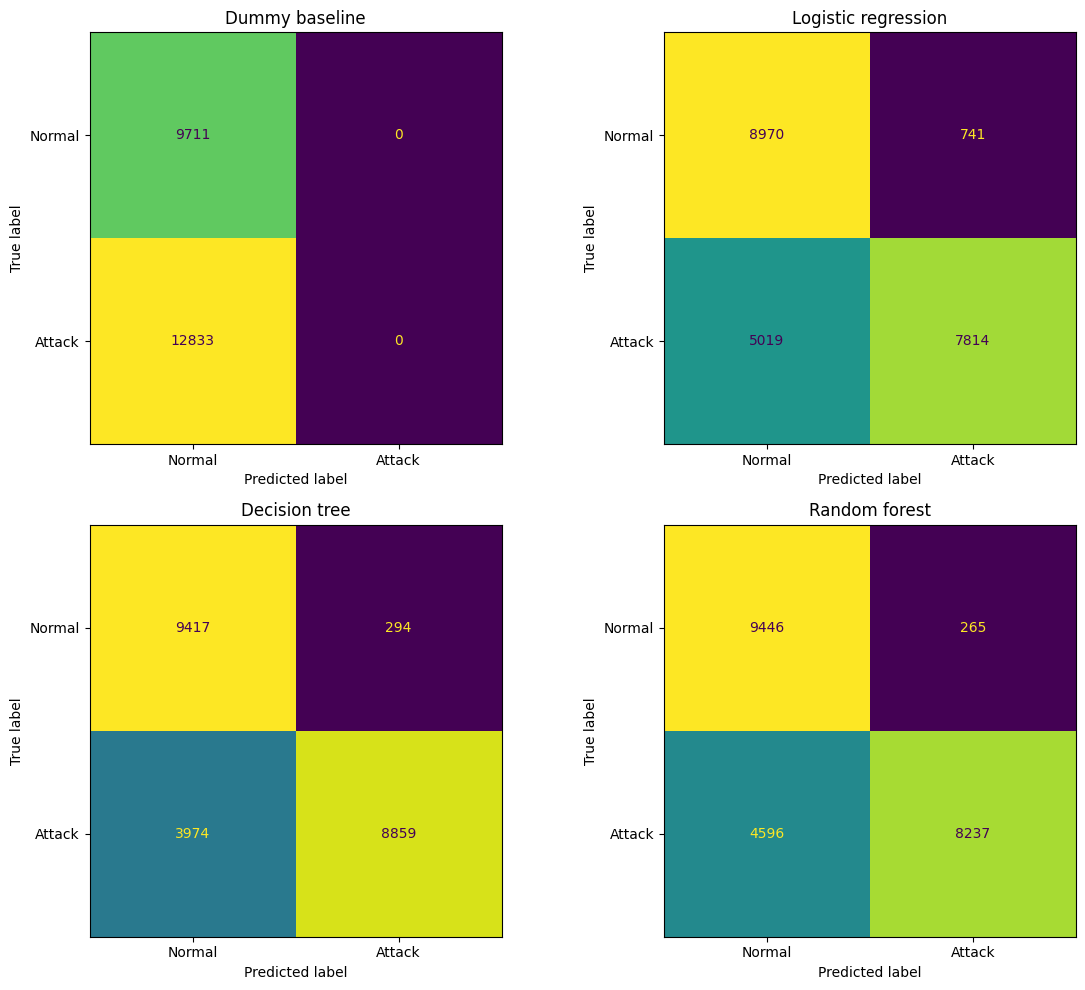

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for axis, model_name in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions_by_model[model_name],
        display_labels=["Normal", "Attack"],
        ax=axis,
        colorbar=False
    )
    axis.set_title(model_name)

plt.tight_layout()
plt.show()

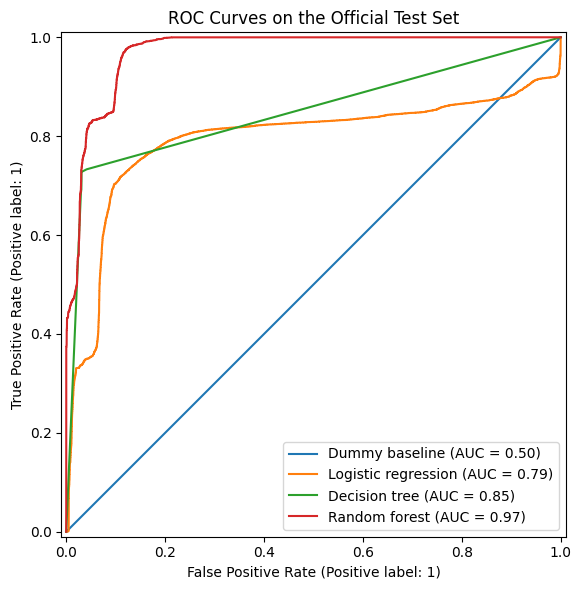

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        scores_by_model[model_name],
        name=model_name,
        ax=ax
    )

ax.set_title("ROC Curves on the Official Test Set")
plt.tight_layout()
plt.show()

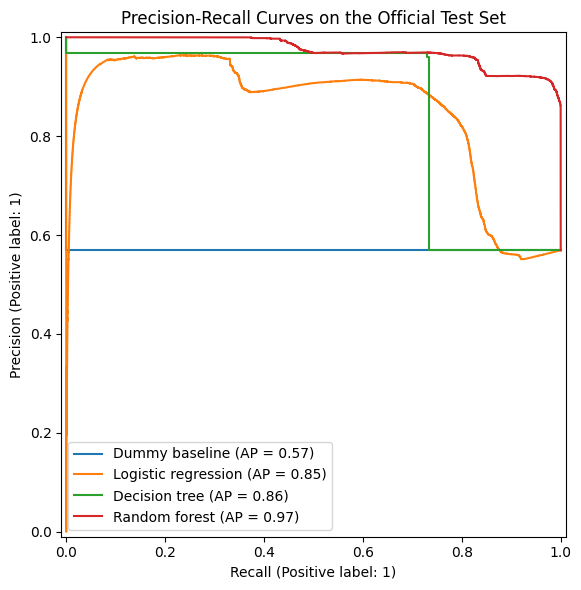

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in models:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        scores_by_model[model_name],
        name=model_name,
        ax=ax
    )

ax.set_title("Precision-Recall Curves on the Official Test Set")
plt.tight_layout()
plt.show()

## 13. Main result interpretation

The best model should not be selected only by accuracy.

For a Network Intrusion Detection System:

- high recall reduces missed attacks;
- high precision reduces unnecessary alerts;
- high MCC indicates balanced performance;
- high F2 is useful when false negatives are especially costly.

The official NSL-KDD test set is harder than an ordinary random split. A lower test score than cross-validation score is evidence of a generalization gap, not necessarily a coding failure.

In [31]:
best_model_name = (
    test_results
    .drop(index="Dummy baseline")
    ["f2"]
    .idxmax()
)

print("Best model according to F2:", best_model_name)
display(test_results.loc[[best_model_name]].round(4))

Best model according to F2: Decision tree


,accuracy,precision,recall,f1,f2,mcc,roc_auc,true_negatives,false_positives,false_negatives,true_positives
model,,,,,,,,,,,
Decision tree,0.8107,0.9679,0.6903,0.8059,0.7323,0.6656,0.8493,9417,294,3974,8859


## 14. Threshold analysis

The default probability threshold is 0.50.

Lowering the threshold usually:

- increases attack recall;
- reduces false negatives;
- increases false positives.

Threshold analysis is shown for interpretation. In a real deployment, the threshold should be chosen on a separate validation set, not on the final test set.

In [32]:
best_scores = scores_by_model[best_model_name]

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    threshold_predictions = (
        best_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        threshold_predictions
    ).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "f2": fbeta_score(
            y_test,
            threshold_predictions,
            beta=2,
            zero_division=0
        ),
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(4))

,threshold,precision,recall,f1,f2,false_positives,false_negatives
0,0.10,0.9676,0.7289,0.8315,0.7667,313,3479
1,0.15,0.9677,0.7288,0.8315,0.7667,312,3480
2,0.20,0.9679,0.7288,0.8315,0.7667,310,3480
3,0.25,0.9678,0.6985,0.8114,0.7397,298,3869
4,0.30,0.9678,0.6985,0.8114,0.7397,298,3869
5,0.35,0.9678,0.6985,0.8114,0.7397,298,3869
6,0.40,0.9676,0.6918,0.8068,0.7336,297,3955
7,0.45,0.9679,0.6904,0.8059,0.7324,294,3973
8,0.50,0.9679,0.6903,0.8059,0.7323,294,3974
9,0.55,0.9679,0.6901,0.8057,0.7321,294,3977


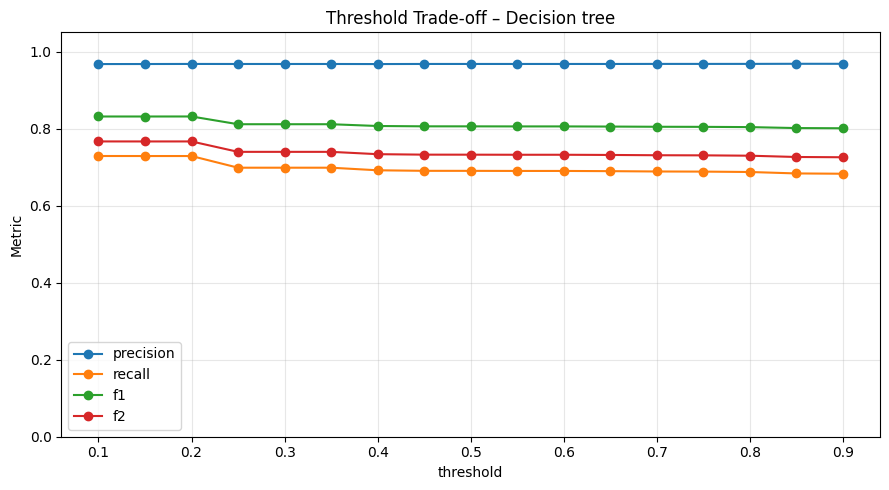

In [33]:
ax = threshold_results.plot(
    x="threshold",
    y=["precision", "recall", "f1", "f2"],
    marker="o",
    figsize=(9, 5)
)

ax.set_title(f"Threshold Trade-off – {best_model_name}")
ax.set_ylabel("Metric")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Lowering the classification threshold increases attack recall but also increases the number of false positives. This demonstrates the classical cybersecurity trade-off between detecting as many attacks as possible and minimizing unnecessary alerts.

In operational environments, the optimal threshold depends on the acceptable balance between security risk and analyst workload.

## 15. Error analysis by attack family

Overall binary metrics can hide important failures.

For example:

- DoS attacks may be easy to detect because they create large traffic effects;
- R2L and U2R attacks may be much harder because they can resemble normal sessions;
- rare attack families can have unstable estimates.

The following analysis measures detection recall for each attack family.

In [34]:
best_predictions = predictions_by_model[best_model_name]

error_df = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": best_predictions,
    "score": best_scores,
    "attack_name": attack_labels_test.to_numpy(),
    "attack_family": attack_families_test.to_numpy()
})

error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["actual"] == 1)
    & (error_df["predicted"] == 0),
    "error_type"
] = "False Negative"

error_df.loc[
    (error_df["actual"] == 0)
    & (error_df["predicted"] == 1),
    "error_type"
] = "False Positive"

display(error_df["error_type"].value_counts().to_frame("count"))

,count
error_type,
Correct,18276
False Negative,3974
False Positive,294


In [35]:
family_performance_rows = []

for family, group in error_df.groupby("attack_family"):
    if family == "Normal":
        normal_specificity = (
            group["predicted"] == 0
        ).mean()

        family_performance_rows.append({
            "attack_family": family,
            "count": len(group),
            "detection_rate_or_specificity": normal_specificity,
            "missed_attacks": np.nan
        })
    else:
        recall = (
            group["predicted"] == 1
        ).mean()

        missed = (
            group["predicted"] == 0
        ).sum()

        family_performance_rows.append({
            "attack_family": family,
            "count": len(group),
            "detection_rate_or_specificity": recall,
            "missed_attacks": missed
        })

family_performance = (
    pd.DataFrame(family_performance_rows)
    .sort_values("detection_rate_or_specificity")
)

display(family_performance.round(4))

,attack_family,count,detection_rate_or_specificity,missed_attacks
3,R2L,2885,0.1823,2359.0
4,U2R,67,0.3284,45.0
2,Probe,2421,0.8269,419.0
0,DoS,7460,0.8457,1151.0
1,Normal,9711,0.9697,NaN


### Interpretation

The error analysis reveals substantial differences across attack families. DoS and Probe attacks achieve relatively high detection rates, whereas R2L and U2R attacks remain much more difficult to classify correctly.

This demonstrates why reporting only overall accuracy can be misleading. A model may appear highly accurate while still failing to detect rare but important attack categories.

In [36]:
attack_name_errors = (
    error_df[error_df["actual"] == 1]
    .groupby("attack_name")
    .agg(
        count=("attack_name", "size"),
        detected=("predicted", "sum"),
        mean_score=("score", "mean")
    )
)

attack_name_errors["recall"] = (
    attack_name_errors["detected"]
    / attack_name_errors["count"]
)

attack_name_errors["missed"] = (
    attack_name_errors["count"]
    - attack_name_errors["detected"]
)

attack_name_errors = attack_name_errors.sort_values(
    ["recall", "count"],
    ascending=[True, False]
)

display(attack_name_errors.head(20).round(4))

,count,detected,mean_score,recall,missed
attack_name,,,,,
guess_passwd,1231,0,0.0177,0.0000,1231
mailbomb,293,0,0.0030,0.0000,293
snmpgetattack,178,0,0.0000,0.0000,178
sendmail,14,0,0.0017,0.0000,14
xlock,9,0,0.0007,0.0000,9
loadmodule,2,0,0.4337,0.0000,2
worm,2,0,0.0030,0.0000,2
imap,1,0,0.0000,0.0000,1
httptunnel,133,13,0.0903,0.0977,120


### Cybersecurity interpretation of errors

#### False negatives

False negatives are attacks classified as normal. They are especially dangerous because they may allow:

- unauthorized access;
- privilege escalation;
- scanning;
- service disruption;
- data compromise.

Rare R2L and U2R attacks are often difficult because they may not create large traffic-volume changes.

#### False positives

False positives are normal connections flagged as attacks. They can:

- overwhelm analysts;
- interrupt normal activity;
- cause alert fatigue;
- reduce trust in the IDS.

A practical threshold must reflect the organization's risk tolerance and analyst capacity.

## 16. Feature importance and explainability

Permutation importance is used because it measures how much model performance decreases when a feature is shuffled.

Advantages:

- model-agnostic;
- connected directly to predictive performance;
- easier to compare than raw tree impurity values.

Limitations:

- correlated features can share importance;
- importance does not imply causality;
- importance is specific to this dataset and model;
- old benchmark importance may not transfer to modern networks.

In [37]:
# Permutation importance can be expensive.
# A fixed sample keeps the notebook practical.

IMPORTANCE_SAMPLE_SIZE = min(5000, len(X_test))

importance_sample = X_test.sample(
    n=IMPORTANCE_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

importance_target = y_test.loc[importance_sample.index]

# scikit-learn does not include "f2" as a built-in scoring string.
# Therefore, we create an explicit F2 scorer.
f2_scorer = make_scorer(
    fbeta_score,
    beta=2,
    zero_division=0
)

permutation = permutation_importance(
    estimator=fitted_models[best_model_name],
    X=importance_sample,
    y=importance_target,
    scoring=f2_scorer,
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importance_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_table.head(15))

,feature,importance_mean,importance_std
0,total_bytes,0.053465,0.003552
1,service,0.047030,0.003377
2,connection_intensity,0.042571,0.002273
3,src_bytes,0.042533,0.004256
4,dst_host_same_src_port_rate,0.011866,0.001211
5,dst_host_srv_serror_rate,0.010352,0.000505
6,dst_host_srv_count,0.008923,0.000730
7,dst_host_serror_rate,0.007749,0.000549
8,duration,0.007203,0.000510
9,src_dst_byte_ratio,0.006758,0.003027


### Interpretation

The permutation importance analysis indicates that traffic volume, service information, and destination-host statistics contribute the most to attack detection.

These findings are consistent with cybersecurity intuition because many attacks produce unusual communication patterns, abnormal service usage, or repetitive connections compared with legitimate traffic.

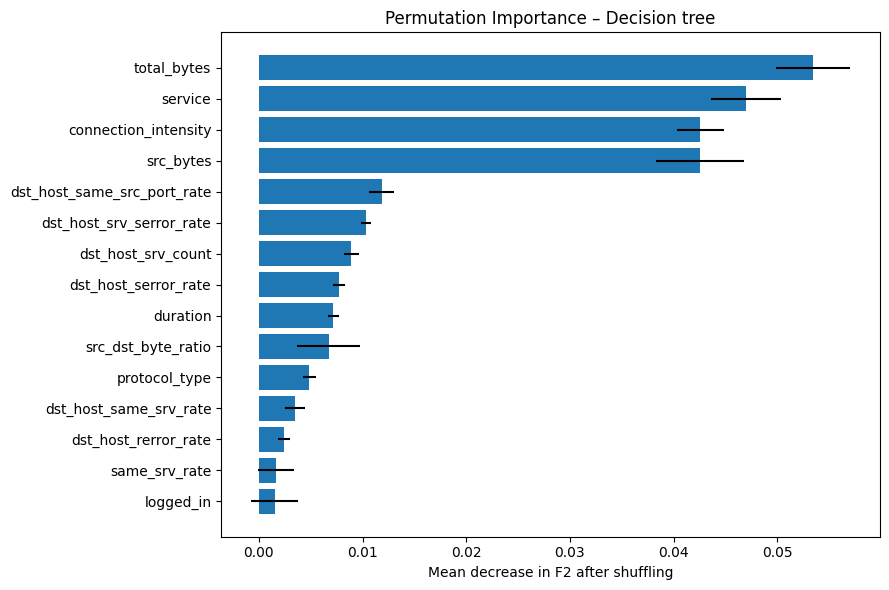

In [38]:
top_importance = importance_table.head(15).sort_values(
    "importance_mean"
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"]
)

ax.set_title(
    f"Permutation Importance – {best_model_name}"
)
ax.set_xlabel("Mean decrease in F2 after shuffling")
plt.tight_layout()
plt.show()

## 17. Optional unsupervised anomaly-detection experiment

The lectures include abnormality detection, so this section adds an exploratory Isolation Forest model.

Important methodological choice:

Isolation Forest is trained only on normal training connections. It then attempts to identify attacks as anomalies.

This is not directly equivalent to supervised classification. It answers a different question:

> Can attacks be detected without using attack labels during model fitting?

Only numerical features are used to keep the experiment interpretable and computationally manageable.

In [39]:
anomaly_features = [
    feature for feature in numerical_features_model
    if feature in X_train.columns
]

normal_train_numeric = (
    X_train.loc[y_train == 0, anomaly_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

test_numeric = (
    X_test[anomaly_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# A fixed sample is enough for this exploratory model.
MAX_NORMAL_ANOMALY_ROWS = 30000

if len(normal_train_numeric) > MAX_NORMAL_ANOMALY_ROWS:
    normal_train_numeric = normal_train_numeric.sample(
        n=MAX_NORMAL_ANOMALY_ROWS,
        random_state=RANDOM_STATE
    )

isolation_forest = IsolationForest(
    n_estimators=250,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_forest.fit(normal_train_numeric)

# IsolationForest returns -1 for anomaly and 1 for normal.
isolation_raw_predictions = isolation_forest.predict(test_numeric)
isolation_predictions = (
    isolation_raw_predictions == -1
).astype(int)

# Larger anomaly score should mean more suspicious.
isolation_scores = -isolation_forest.decision_function(test_numeric)

isolation_metrics = {
    "accuracy": accuracy_score(
        y_test,
        isolation_predictions
    ),
    "precision": precision_score(
        y_test,
        isolation_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        isolation_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        isolation_predictions,
        zero_division=0
    ),
    "f2": fbeta_score(
        y_test,
        isolation_predictions,
        beta=2,
        zero_division=0
    ),
    "mcc": matthews_corrcoef(
        y_test,
        isolation_predictions
    ),
    "roc_auc": roc_auc_score(
        y_test,
        isolation_scores
    )
}

display(
    pd.DataFrame(
        isolation_metrics,
        index=["Isolation Forest"]
    ).round(4)
)

,accuracy,precision,recall,f1,f2,mcc,roc_auc
Isolation Forest,0.7939,0.9738,0.6556,0.7836,0.7014,0.644,0.927


### Unsupervised experiment interpretation

Isolation Forest may detect unusual traffic, but not every attack is statistically unusual. Some attacks imitate normal connections, while some legitimate connections are rare.

Therefore, unsupervised anomaly detection can complement a supervised IDS, but it should not automatically replace it.

## 18. Critical evaluation of the selected source

### Main claims

The source presents Random Forest, KNN, SVC, and ensemble learning as effective approaches for intrusion detection on NSL-KDD and compares them mainly through accuracy.

### Strengths

1. The source uses a recognized cybersecurity benchmark.
2. The repository includes code and data.
3. Multiple model families are compared.
4. The project is understandable and relatively easy to reproduce.
5. The use of ensemble learning is reasonable for nonlinear network data.

### Weaknesses

1. **Accuracy receives too much emphasis.**  
   Accuracy alone does not show how many attacks are missed or how many false alerts are generated.

2. **Limited error analysis.**  
   Overall binary accuracy hides differences between DoS, Probe, R2L, and U2R attacks.

3. **Insufficient discussion of class prevalence.**  
   Benchmark prevalence differs from real network environments.

4. **Feature-engineering decisions are not fully justified.**  
   Categorical encoding, scaling, skewness, and feature redundancy require explanation.

5. **Possible preprocessing leakage risk.**  
   Preprocessing should be fitted only on training data and preferably inside pipelines.

6. **Limited reproducibility documentation.**  
   Package versions and a formal environment file are not provided.

7. **No temporal validation.**  
   The dataset contains no timestamps and represents old network behavior.

8. **No threshold or cost analysis.**  
   The operational cost of false negatives and false positives is not considered.

9. **No comparison with a trivial baseline.**  
   A dummy classifier helps show whether models add real value.

10. **No external modern dataset.**  
    Performance on NSL-KDD does not establish performance on current enterprise traffic.

### Are the conclusions justified?

The results can support the narrow conclusion that classical machine-learning models learn useful patterns in NSL-KDD.

They do not justify a broad conclusion that the same models are ready for real-world modern intrusion detection. A production claim would require:

- current traffic;
- temporal testing;
- external validation;
- probability calibration;
- deployment-specific thresholds;
- drift monitoring;
- adversarial robustness evaluation.

## Lessons Learned

Several important observations emerged during this project.

- Cross-validation produced higher scores than evaluation on the official test set, indicating that the official test set provides a more challenging and realistic assessment.

- Overall accuracy alone is insufficient for intrusion detection because rare attack families may still have poor detection rates.

- Feature engineering improved both interpretability and predictive performance by incorporating cybersecurity knowledge into the analysis.

- Decision thresholds have a significant impact on the trade-off between missed attacks and false alarms.

## 19. Reproducibility analysis

### Available materials

- public GitHub code;
- public training and test files;
- recognizable model definitions;
- benchmark documentation.

### Reproducibility limitations

- the official UNB page no longer directly distributes the files;
- data must be obtained from mirrors;
- exact Python and library versions are not pinned;
- all preprocessing assumptions are not documented;
- the original traffic-generation process cannot be rerun from raw modern traffic;
- no timestamps are available;
- no current external validation is included.

### Overall judgment

The model-training experiment is reasonably reproducible. The complete scientific pipeline—from traffic capture to deployable modern IDS—is not fully reproducible.

## 20. Conclusions

This project reproduced and extended a public NSL-KDD intrusion-detection project.

Main findings:

- NSL-KDD contains useful predictive structure for binary intrusion detection.
- The official test set is more informative than a random split because it evaluates generalization to a different distribution.
- Accuracy alone is insufficient.
- Recall and F2 are important when missed attacks are costly.
- Precision is important because false alerts can overwhelm analysts.
- MCC gives a more balanced summary than accuracy alone.
- Attack-family analysis reveals weaknesses that overall metrics hide.
- R2L and U2R attacks may be harder to detect than high-volume DoS behavior.
- Feature importance supports interpretation, but it does not prove causal security mechanisms.
- The absence of timestamps prevents concept-drift evaluation.
- The age and artificial nature of NSL-KDD limit real-world conclusions.

### Final recommendation

The selected project is useful as a teaching example and benchmark comparison. It should not be deployed directly as a modern intrusion-detection system.

A stronger future system should use current network-flow data, temporal validation, external datasets, calibrated probabilities, cost-sensitive thresholds, rare-attack evaluation, and continuous monitoring.

## Final Reflection

This project demonstrated that classical machine-learning algorithms remain effective for network intrusion detection on the NSL-KDD benchmark. However, the experiments also highlighted several important limitations.

Performance on the official test set was substantially lower than cross-validation performance, suggesting that generalization to unseen attack patterns remains challenging. In addition, the detailed error analysis showed that rare attack categories such as R2L and U2R remain significantly harder to detect than common DoS attacks.

These findings emphasize the importance of evaluating intrusion-detection systems using multiple complementary metrics instead of relying solely on overall accuracy. They also highlight the need for modern datasets, continuous model updates, and deployment-specific threshold selection before operational use.

## 21. Executive summary

This project critically evaluates a public GitHub implementation of machine-learning-based network intrusion detection using the NSL-KDD dataset. The selected source applies Random Forest, K-Nearest Neighbors, Support Vector Classification, and ensemble learning, and compares the models mainly through classification accuracy.

NSL-KDD contains 41 connection features, an attack label, and a difficulty score. The data includes continuous and discrete traffic measurements together with categorical protocol, service, and connection-state fields. The official train and test sets are retained because they provide a more demanding generalization test than randomly splitting one combined dataset.

The notebook performs a full data-science workflow. It checks feature types, missing values, duplicated observations, constant features, class prevalence, categorical distributions, numerical skewness, rare behavior, IQR-based outliers, Spearman correlations, and feature redundancy. Temporal analysis is discussed explicitly, but cannot be conducted because the dataset has no timestamps. This absence is an important limitation because attack behavior and network technology change over time.

The preprocessing pipeline removes the difficulty score and constant features, one-hot encodes categorical variables, transforms strongly skewed non-negative variables using log(1+x), standardizes numerical variables for logistic regression, and creates domain-informed aggregate features. Preprocessing is placed inside scikit-learn pipelines to prevent train-test leakage.

A dummy baseline, logistic regression, decision tree, and random forest are compared through stratified cross-validation on the official training set. Final models are trained on all training records and evaluated on the official test set. Accuracy, precision, recall, F1, F2, Matthews correlation coefficient, ROC-AUC, confusion matrices, ROC curves, and precision-recall curves are reported. F2 is emphasized because missing an attack may be more costly than investigating an additional alert.

The project also includes threshold analysis, attack-family error analysis, attack-name recall, permutation feature importance, and an exploratory Isolation Forest experiment trained only on normal traffic. These analyses show why a single accuracy value is not enough for an intrusion-detection system.

The selected source demonstrates that classical machine-learning models can learn useful patterns in NSL-KDD. However, its broader practical implications are limited. The dataset is old, contains no temporal information, differs from modern network traffic, and cannot establish production readiness. The source also lacks detailed cost-sensitive evaluation, attack-family analysis, probability-threshold discussion, and external validation.

The final conclusion is that this project is useful as an educational and benchmarking exercise, but it should not be used directly for modern operational intrusion detection. Future work should use recent temporally labeled traffic, multiple external datasets, calibrated probabilities, rare-attack evaluation, adversarial testing, and continuous drift monitoring.

## 22. Save outputs for the report

The following cell saves the main tables.

In [40]:
OUTPUT_DIR = Path("project_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

cv_results.to_csv(
    OUTPUT_DIR / "cross_validation_results.csv"
)

test_results.to_csv(
    OUTPUT_DIR / "official_test_results.csv"
)

family_performance.to_csv(
    OUTPUT_DIR / "attack_family_performance.csv",
    index=False
)

attack_name_errors.to_csv(
    OUTPUT_DIR / "attack_name_errors.csv"
)

importance_table.to_csv(
    OUTPUT_DIR / "permutation_importance.csv",
    index=False
)

threshold_results.to_csv(
    OUTPUT_DIR / "threshold_analysis.csv",
    index=False
)

outlier_summary.to_csv(
    OUTPUT_DIR / "outlier_summary.csv",
    index=False
)

high_corr_pairs.to_csv(
    OUTPUT_DIR / "high_correlation_pairs.csv",
    index=False
)

print("Saved output files:")

for output_file in sorted(OUTPUT_DIR.iterdir()):
    print("-", output_file)

Saved output files:
- project_outputs/attack_family_performance.csv
- project_outputs/attack_name_errors.csv
- project_outputs/cross_validation_results.csv
- project_outputs/high_correlation_pairs.csv
- project_outputs/official_test_results.csv
- project_outputs/outlier_summary.csv
- project_outputs/permutation_importance.csv
- project_outputs/threshold_analysis.csv
